# Modeling -- Subscription Churn

Runs the same training pipeline as `python -m churn.modeling.train`
(imported directly from `churn.modeling.train`, not reimplemented here), so
the numbers in this notebook are produced by the exact code shipped in
`src/churn/`, not a separate notebook-only copy. It covers: baseline vs.
main model, stratified k-fold cross-validation, calibration, decision
threshold selection, and SHAP-based feature attribution.

In [1]:
from IPython.display import Image, display

from churn.modeling import train as train_module

results = train_module.main(argv=[])

C:\Users\tahaa\portfolio-review\Chrun_prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


2026/09/15 22:19:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/09/15 22:19:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


{
  "n_customers": 20000,
  "churn_rate": 0.22765,
  "decision_threshold": 0.2673184822003047,
  "oof_brier_raw": 0.16806959752275447,
  "oof_brier_calibrated": 0.13059351979633585,
  "used_calibrated_model": true,
  "baseline": {
    "roc_auc": 0.8003041137082506,
    "pr_auc": 0.5888286161746404,
    "f1": 0.46554110157763634,
    "threshold": 0.2673184822003047,
    "confusion_matrix": [
      [
        1228,
        1861
      ],
      [
        70,
        841
      ]
    ]
  },
  "baseline_run_id": "fe8452326305426b80ca59da80ddfe3e",
  "shap_summary_path": "C:\\Users\\tahaa\\portfolio-review\\Chrun_prediction\\reports\\shap_summary.png",
  "cv": {
    "n_splits": 5,
    "roc_auc_mean": 0.8095931852262004,
    "roc_auc_std": 0.0071065747762206685,
    "pr_auc_mean": 0.6024014104745312,
    "pr_auc_std": 0.008573006634708873,
    "f1_mean": 0.5591415727282758,
    "f1_std": 0.0076594772341976956,
    "decision_threshold": 0.2673184822003047
  },
  "main_raw": {
    "roc_auc": 0.803

## Cross-validated performance (main model, training split only)

In [2]:
cv = results["cv"]
print(f"Folds: {cv['n_splits']}")
print(f"ROC-AUC: {cv['roc_auc_mean']:.4f} +/- {cv['roc_auc_std']:.4f}")
print(f"PR-AUC:  {cv['pr_auc_mean']:.4f} +/- {cv['pr_auc_std']:.4f}")
print(f"F1:      {cv['f1_mean']:.4f} +/- {cv['f1_std']:.4f}")

Folds: 5
ROC-AUC: 0.8096 +/- 0.0071
PR-AUC:  0.6024 +/- 0.0086
F1:      0.5591 +/- 0.0077


## Baseline vs. main model on the held-out test set

In [3]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "baseline_logreg": results["baseline"],
        "main_xgboost": results["main_final"],
    }
).loc[["roc_auc", "pr_auc", "f1", "threshold"]]
comparison

,baseline_logreg,main_xgboost
roc_auc,0.800304,0.801417
pr_auc,0.588829,0.600919
f1,0.465541,0.550962
threshold,0.267318,0.267318


The decision threshold above was chosen by maximizing F1 on cross-validated
out-of-fold predictions from the training split (see
`churn.modeling.evaluate.select_f1_optimal_threshold`) -- the test set was
never used to pick it, so this comparison is not threshold-cherry-picked
against the test data.

## Calibration

Used calibrated model: True
Out-of-fold Brier score, raw:        0.1681
Out-of-fold Brier score, calibrated: 0.1306


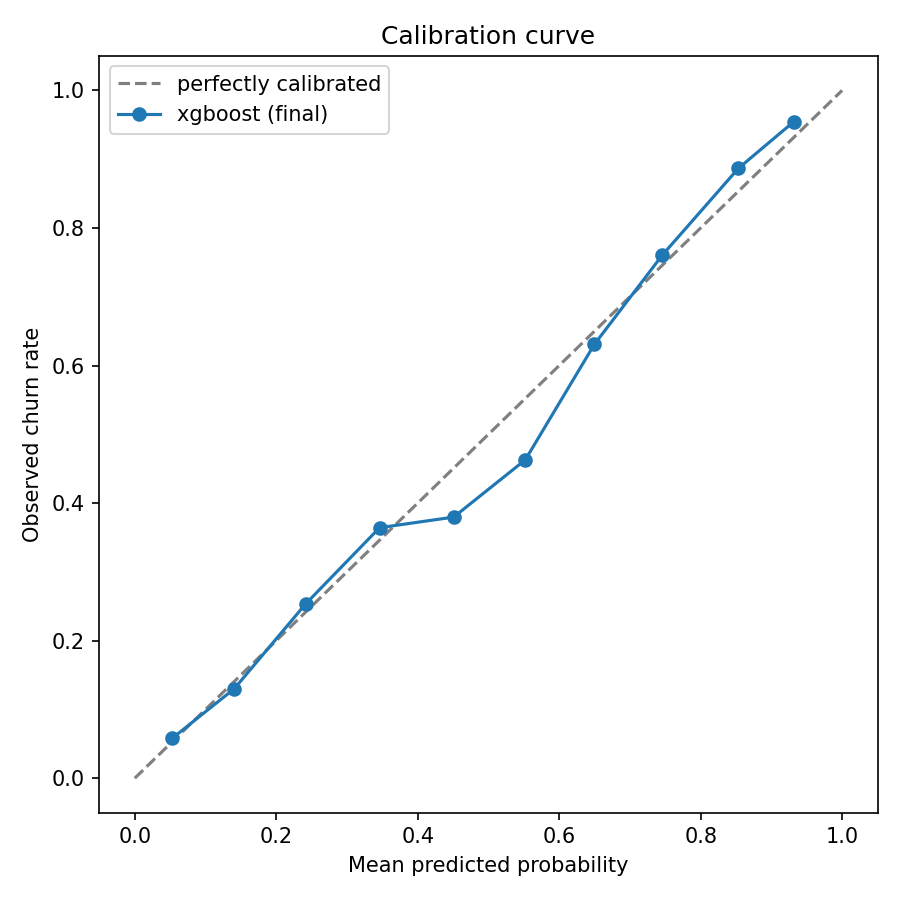

In [4]:
print(f"Used calibrated model: {results['used_calibrated_model']}")
print(f"Out-of-fold Brier score, raw:        {results['oof_brier_raw']:.4f}")
print(f"Out-of-fold Brier score, calibrated: {results['oof_brier_calibrated']:.4f}")
display(Image(filename=results["calibration_curve_path"]))

Calibration is selected by comparing the Brier score on out-of-fold
training predictions (never on the test set), so the raw-vs-calibrated
choice cannot leak test information either.

## Feature attribution (SHAP)

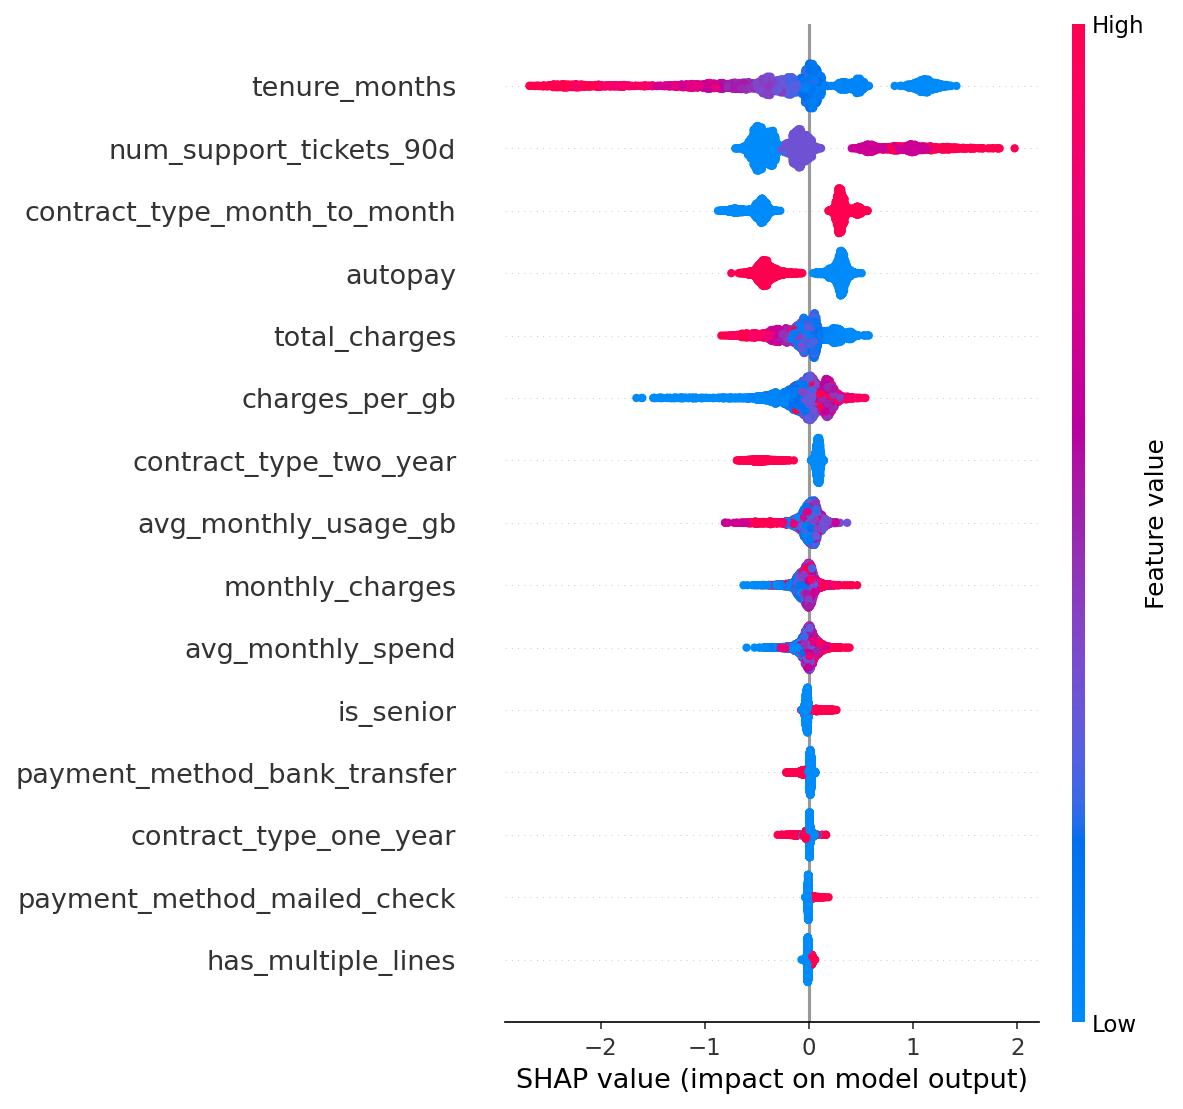

In [5]:
if "shap_summary_path" in results:
    display(Image(filename=results["shap_summary_path"]))
else:
    print("SHAP summary was not generated in this run -- see stderr in the training log.")

## Summary

- The main XGBoost model is compared against a logistic-regression baseline
  on identical train/test splits, oversampling, and decision threshold.
- Model selection (calibrated vs. raw) and threshold tuning both use only
  cross-validated training-split predictions -- the test set is touched
  exactly once, for the final numbers shown above.
- See `README.md` for the headline numbers from the run this repository
  ships with, and `MODEL_CARD.md` for limitations and ethical
  considerations before any real-world use.